# 05. Tree Models, Path Logic, and Segment Rules

The previous notebook studied shape constraints: rules about how predictions should move when one feature changes. This notebook studies a different kind of interpretability: **path logic**. A decision tree explains a prediction by routing an observation through a sequence of splits until it lands in a terminal segment.

That structure is attractive for decision science because it resembles operational triage. A model can say: accounts with recent incidents above a threshold, weak adoption, and no executive sponsor belong to a high-risk segment. This is much easier to discuss with stakeholders than a large vector of coefficients or a black-box ensemble.

But tree interpretability is fragile. A tree is readable only while its paths are short, its leaves have enough support, and its split logic is stable enough to trust. This notebook treats a tree as a segment-discovery tool, not as a magical explanation machine.

## Learning Objectives

By the end of this notebook, you should be able to:

1. Explain how CART-style trees recursively partition a feature space.
2. Read a tree prediction as a conjunction of path conditions.
3. Compute impurity reduction and understand why a split is selected.
4. Extract terminal-leaf segment rules from a fitted decision tree.
5. Compare shallow, deeper, pruned, and unpruned trees using predictive and interpretability metrics.
6. Evaluate segment quality using support, event rate, lift, and out-of-sample reliability.
7. Diagnose when a tree path is too small, too unstable, or too complex for decision use.
8. Explain why ensembles improve predictive performance while weakening single-path interpretability.

In [1]:
# Section focus: Learning Objectives.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

import sys
import warnings
from pathlib import Path

import graphviz
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Image, display
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    log_loss,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_graphviz, export_text

for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / 'notebooks' / '_shared' / 'display.py').exists():
        if str(candidate) not in sys.path:
            sys.path.insert(0, str(candidate))
        break

from notebooks._shared.display import smart_display

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.float_format', lambda x: f'{x:0.3f}')
pd.set_option('display.max_columns', 80)
pd.set_option('display.max_colwidth', 220)
np.random.seed(2028)

FEATURES = [
    'open_tickets_30d',
    'recent_incidents_90d',
    'integration_complexity',
    'payment_delay_days',
    'usage_volatility',
    'training_completion',
    'product_adoption',
    'executive_sponsor',
    'enterprise_segment',
    'international_region',
    'pooled_support_motion',
]

FEATURE_LABELS = {
    'open_tickets_30d': 'Open tickets in last 30 days',
    'recent_incidents_90d': 'Recent incidents in last 90 days',
    'integration_complexity': 'Integration complexity',
    'payment_delay_days': 'Payment delay days',
    'usage_volatility': 'Usage volatility',
    'training_completion': 'Training completion',
    'product_adoption': 'Product adoption',
    'executive_sponsor': 'Executive sponsor present',
    'enterprise_segment': 'Enterprise segment',
    'international_region': 'International region',
    'pooled_support_motion': 'Pooled support motion',
}

TARGET = 'needs_specialist_review'

## 1. CART Logic In One Page

A classification tree partitions the feature space into terminal regions $R_1,\ldots,R_M$. Within a terminal region, the predicted event probability is usually the event rate in that region:

$$
\hat p_m = \frac{1}{|R_m|}\sum_{i:x_i\in R_m} y_i.
$$

A tree prediction can be written as a piecewise-constant function:

$$
\hat p(x) = \sum_{m=1}^M \hat p_m \mathbf{1}\{x\in R_m\}.
$$

The CART algorithm builds those regions recursively. At a candidate node $A$, it considers splits of the form

$$
x_j \le s
\quad \text{versus} \quad
x_j > s.
$$

For binary classification, a common impurity measure is Gini impurity:

$$
G(A)=2\hat p_A(1-\hat p_A),
$$

where $\hat p_A$ is the event rate inside node $A$. A split is attractive when it reduces weighted impurity:

$$
\Delta G
= G(A)
- \frac{n_L}{n_A}G(A_L)
- \frac{n_R}{n_A}G(A_R).
$$

This greedy splitting procedure is why trees are easy to read and also why they can be unstable. A small change in data can slightly change a high-level split, and that can alter many downstream path rules. Breiman et al.'s CART framework made this recursive partitioning approach central to modern decision trees, while later work on bagging and ensembles studied how aggregation can reduce instability at the cost of single-tree readability (Breiman et al., 1984; Buhlmann & Yu, 2002).

### Path Logic As Segment Logic

A root-to-leaf path is a rule. For example:

$$
\text{recent incidents} > 1.5
\quad \land \quad
\text{product adoption} \le 0.45
\quad \land \quad
\text{executive sponsor}=0.
$$

This is a segment definition. The model assigns a score and creates a named operational group. In decision systems, that matters because segments can be inspected, named, challenged, monitored, and translated into different actions.

## 2. Synthetic Case Study: Specialist Review Segments

We continue the customer-success triage setting. The organization must decide which accounts should receive proactive specialist review. The target is `needs_specialist_review`.

This notebook uses a data-generating process with threshold-like operational patterns so that tree paths become meaningful. Examples include:

| Latent operational pattern | Why a tree can discover it |
|---|---|
| High backlog plus multiple incidents | A split on tickets followed by a split on incidents defines a high-burden segment |
| Low training completion plus weak adoption | Two threshold conditions define a weak-enablement segment |
| Payment friction with no executive sponsor | A tree path can represent a governance-risk segment |
| Complex integration with no sponsor | A path can isolate accounts that need escalation rather than generic support |

These are still predictive segments, not causal effects. If a tree says a segment has high risk, it does not prove that changing one variable would reduce risk. It says that accounts matching that path had higher observed risk under the modeled data-generating process.

In [2]:
# Section focus: 2. Synthetic Case Study: Specialist Review Segments.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def sigmoid(x):
    """Map a linear score to a probability-like value for the notebook simulation.
    
    Parameters
    ----------
    x : object
        Numeric score, scalar, or array passed through the transformation in this helper.
    
    Returns
    -------
    object
        Numeric diagnostic, score, or transformed value from the sigmoid calculation.
    """
    return 1 / (1 + np.exp(-np.clip(x, -30, 30)))


def make_tree_segment_dataset(n=7200, seed=2028):
    """Construct the tree segment dataset helper used in the 05. Tree Models, Path Logic, and Segment Rules workflow.
    
    Parameters
    ----------
    n : object
        Number of observations or simulation units used by the calculation.
    seed : object
        Random seed used to make the simulation reproducible.
    
    Returns
    -------
    object
        pandas.DataFrame containing the tabular result produced by this function.
    """
    rng = np.random.default_rng(seed)

    segment = rng.choice(['growth', 'mid-market', 'enterprise'], size=n, p=[0.48, 0.33, 0.19])
    region = rng.choice(['North', 'South', 'West', 'International'], size=n, p=[0.31, 0.22, 0.29, 0.18])
    support_motion = rng.choice(['reactive', 'pooled', 'dedicated'], size=n, p=[0.50, 0.34, 0.16])

    enterprise_segment = (segment == 'enterprise').astype(int)
    international_region = (region == 'International').astype(int)
    pooled_support_motion = (support_motion == 'pooled').astype(int)

    executive_sponsor = rng.binomial(
        1,
        np.clip(0.24 + 0.20 * (segment == 'mid-market') + 0.47 * enterprise_segment - 0.06 * international_region, 0.05, 0.90),
        size=n,
    )
    open_tickets_30d = rng.poisson(
        np.clip(1.2 + 1.1 * (segment == 'mid-market') + 2.2 * enterprise_segment + 0.65 * pooled_support_motion, 0.2, None)
    )
    recent_incidents_90d = rng.poisson(
        np.clip(0.20 + 0.24 * open_tickets_30d + 0.14 * pooled_support_motion + 0.10 * international_region, 0.03, None)
    )
    integration_complexity = np.clip(
        rng.normal(4.1 + 0.9 * (segment == 'mid-market') + 1.7 * enterprise_segment + 0.35 * international_region, 1.25, n),
        1.0,
        10.0,
    )
    usage_volatility = np.clip(rng.gamma(shape=2.1, scale=0.43, size=n) + 0.16 * pooled_support_motion, 0.03, 4.2)
    training_completion = np.clip(
        0.77 + 0.12 * rng.normal(size=n) - 0.09 * pooled_support_motion - 0.05 * international_region - 0.03 * enterprise_segment,
        0.03,
        0.99,
    )
    product_adoption = np.clip(
        0.64 + 0.12 * rng.normal(size=n) + 0.09 * executive_sponsor - 0.07 * usage_volatility - 0.025 * integration_complexity,
        0.03,
        0.99,
    )
    payment_delay_days = np.clip(
        rng.gamma(shape=1.7, scale=2.1, size=n) + 1.1 * international_region + 0.25 * (segment == 'growth'),
        0.0,
        35.0,
    )

    high_burden = ((open_tickets_30d >= 5) & (recent_incidents_90d >= 2)).astype(int)
    weak_enablement = ((training_completion < 0.55) & (product_adoption < 0.45)).astype(int)
    commercial_friction = ((payment_delay_days > 8) & (executive_sponsor == 0)).astype(int)
    complex_without_sponsor = ((integration_complexity > 6.8) & (executive_sponsor == 0)).astype(int)

    logit = (
        -5.2
        + 0.21 * open_tickets_30d
        + 0.43 * recent_incidents_90d
        + 0.19 * integration_complexity
        + 0.06 * payment_delay_days
        + 0.72 * usage_volatility
        + 1.15 * (1 - training_completion)
        + 0.85 * (1 - product_adoption)
        - 0.75 * executive_sponsor
        + 0.37 * enterprise_segment
        + 0.22 * international_region
        + 0.23 * pooled_support_motion
        + 0.95 * high_burden
        + 0.65 * weak_enablement
        + 0.55 * commercial_friction
        + 0.45 * complex_without_sponsor
    )
    needs_specialist_review = rng.binomial(1, sigmoid(logit), size=n)

    return pd.DataFrame(
        {
            'segment': segment,
            'region': region,
            'support_motion': support_motion,
            'open_tickets_30d': open_tickets_30d,
            'recent_incidents_90d': recent_incidents_90d,
            'integration_complexity': integration_complexity,
            'payment_delay_days': payment_delay_days,
            'usage_volatility': usage_volatility,
            'training_completion': training_completion,
            'product_adoption': product_adoption,
            'executive_sponsor': executive_sponsor,
            'enterprise_segment': enterprise_segment,
            'international_region': international_region,
            'pooled_support_motion': pooled_support_motion,
            'high_burden': high_burden,
            'weak_enablement': weak_enablement,
            'commercial_friction': commercial_friction,
            'complex_without_sponsor': complex_without_sponsor,
            'needs_specialist_review': needs_specialist_review,
        }
    )


df = make_tree_segment_dataset()
train_df, test_df = train_test_split(
    df,
    test_size=0.30,
    random_state=2028,
    stratify=df[TARGET],
)

X_train = train_df[FEATURES]
y_train = train_df[TARGET]
X_test = test_df[FEATURES]
y_test = test_df[TARGET]

summary = pd.DataFrame(
    [
        {'quantity': 'Rows', 'value': len(df)},
        {'quantity': 'Train rows', 'value': len(train_df)},
        {'quantity': 'Test rows', 'value': len(test_df)},
        {'quantity': 'Specialist-review rate', 'value': df[TARGET].mean()},
        {'quantity': 'High-burden segment share', 'value': df['high_burden'].mean()},
        {'quantity': 'Weak-enablement segment share', 'value': df['weak_enablement'].mean()},
        {'quantity': 'Commercial-friction segment share', 'value': df['commercial_friction'].mean()},
    ]
)

latent_segment_summary = (
    df[['high_burden', 'weak_enablement', 'commercial_friction', 'complex_without_sponsor', TARGET]]
    .melt(id_vars=TARGET, var_name='latent_pattern', value_name='in_pattern')
    .query('in_pattern == 1')
    .groupby('latent_pattern', as_index=False)
    .agg(rows=('in_pattern', 'size'), event_rate=(TARGET, 'mean'))
    .sort_values('event_rate', ascending=False)
)

smart_display(summary.round(3))
smart_display(latent_segment_summary.round(3))
smart_display(df[FEATURES + [TARGET]].head(6))

,quantity,value
0,Rows,7200.000000
1,Train rows,5040.000000
2,Test rows,2160.000000
3,Specialist-review rate,0.194000
4,High-burden segment share,0.051000
5,Weak-enablement segment share,0.034000
6,Commercial-friction segment share,0.055000


,latent_pattern,rows,event_rate
2,high_burden,369,0.688
3,weak_enablement,247,0.486
1,complex_without_sponsor,270,0.437
0,commercial_friction,398,0.347


,open_tickets_30d,recent_incidents_90d,integration_complexity,payment_delay_days,usage_volatility,training_completion,product_adoption,executive_sponsor,enterprise_segment,international_region,pooled_support_motion,needs_specialist_review
0,1,2,3.290,2.720,0.429,0.818,0.614,0,0,0,0,0
1,0,0,5.105,3.869,0.673,0.670,0.571,1,0,0,1,0
2,5,1,2.483,1.585,0.255,0.720,0.933,1,0,0,0,0
3,4,1,5.188,2.473,0.420,0.574,0.733,1,1,0,0,0
4,6,0,3.496,3.339,0.964,0.807,0.638,1,1,0,0,0
5,4,0,4.114,9.026,0.812,0.822,0.342,0,0,0,1,0


The latent-pattern table is not information the model receives directly. It is there for us as notebook authors and analysts. The fitted tree only sees the raw operational features.

A useful tree should recover some of these operational patterns through path conditions. A poor tree may either miss them or discover segments that are too small and too unstable to be useful.

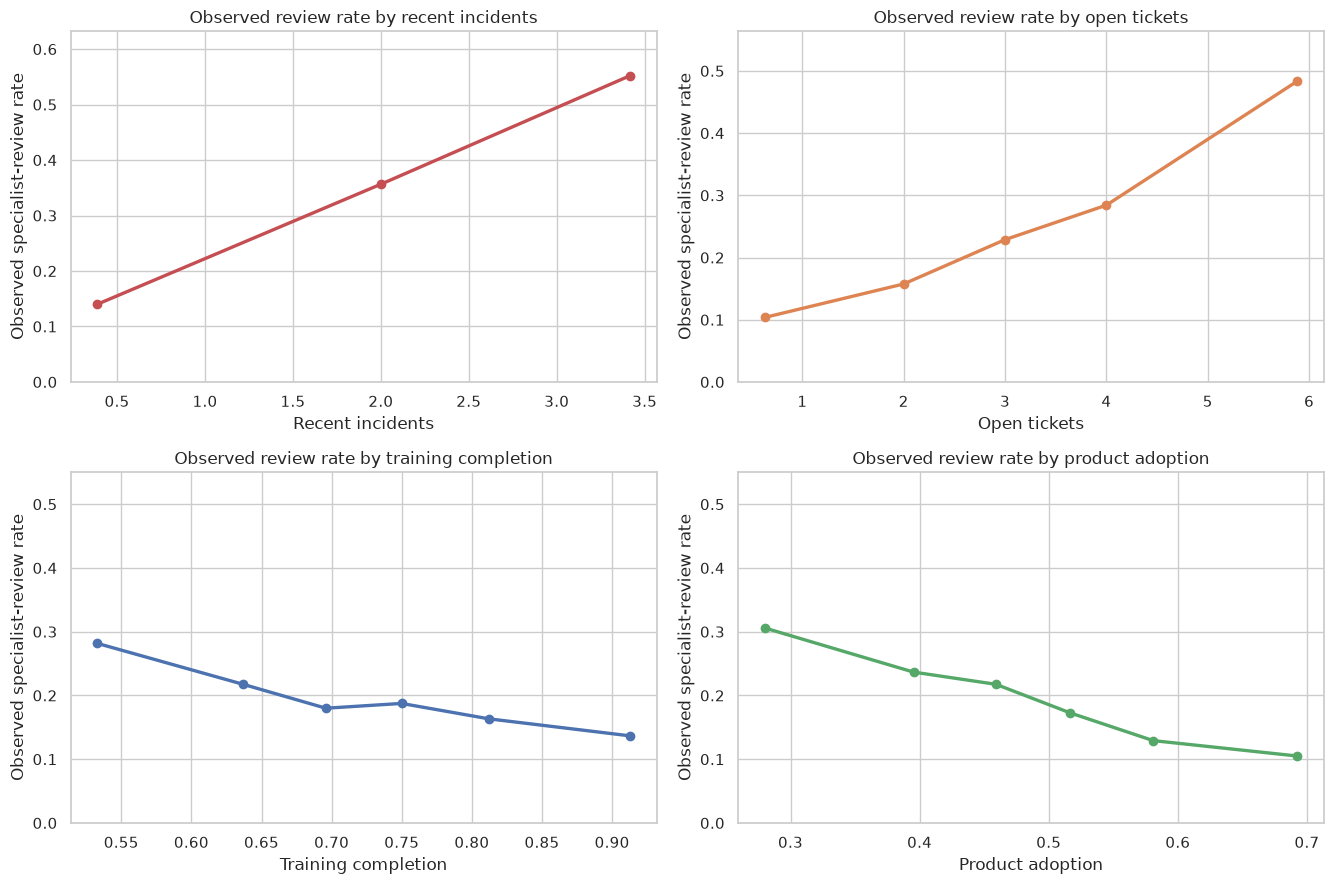

In [3]:
# Section focus: Discussion.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def event_rate_by_bin(df, feature, target=TARGET, q=6):
    """Carry out the event rate by bin step used in the 05. Tree Models, Path Logic, and Segment Rules workflow.
    
    Parameters
    ----------
    df : object
        Input data frame containing the rows used in this notebook example.
    feature : object
        Column or variable name used to select information from the input table.
    target : object
        Target column name or target values used by the supervised task.
    q : object
        Quantile level used by the risk, interval, or tail calculation.
    
    Returns
    -------
    object
        Intermediate result produced by the event rate by bin calculation and reused by later cells.
    """
    return (
        df.groupby(pd.qcut(df[feature], q=q, duplicates='drop'), observed=False)
        .agg(mean_feature=(feature, 'mean'), event_rate=(target, 'mean'), rows=(target, 'size'))
        .reset_index(drop=True)
    )


fig, axes = plt.subplots(2, 2, figsize=(13.5, 9.0))
plot_specs = [
    ('recent_incidents_90d', 'Recent incidents', '#c44e52'),
    ('open_tickets_30d', 'Open tickets', '#dd8452'),
    ('training_completion', 'Training completion', '#4c72b0'),
    ('product_adoption', 'Product adoption', '#55a868'),
]

for ax, (feature, label, color) in zip(axes.ravel(), plot_specs):
    curve = event_rate_by_bin(df, feature)
    ax.plot(curve['mean_feature'], curve['event_rate'], marker='o', linewidth=2.4, color=color)
    ax.set_title(f'Observed review rate by {label.lower()}')
    ax.set_xlabel(label)
    ax.set_ylabel('Observed specialist-review rate')
    ax.set_ylim(0, max(0.55, curve['event_rate'].max() + 0.08))

plt.tight_layout()
plt.show()

This result is an interpretation diagnostic. For Synthetic Case Study: Specialist Review Segments, look at whether the explanation is stable, plausible, and useful for stakeholder review. Explanation instability should be visible to the stakeholder, since it changes how much weight the story can carry.


## 3. Fit Trees With Different Complexity Levels

Tree interpretability depends heavily on complexity. A tree with 8 leaves can often be read. A tree with 150 leaves is technically a tree, but no longer a practical explanation.

We compare four model types:

| Model | Purpose |
|---|---|
| Shallow tree | Simple path logic, easy to explain |
| Medium tree | More flexible path logic, still partly readable |
| Unpruned tree | Shows what happens when readability and generalization are ignored |
| Random forest | Stronger predictive benchmark, weaker single-path explanation |

The random forest is not included as the main explanation object. It is included to show why practitioners often move from single trees to ensembles: aggregation improves predictive performance and reduces variance, but the explanation shifts from one readable path to aggregate diagnostics.

,model,roc_auc,average_precision,brier_score,log_loss,precision_at_0.50,recall_at_0.50,complexity
4,Random forest depth 6,0.789,0.511,0.127,0.406,0.676,0.174,"200 trees, max depth 6"
2,Medium tree depth 6,0.755,0.456,0.131,0.421,0.590,0.226,"depth 6, 22 leaves"
3,Unpruned tree,0.730,0.420,0.145,1.164,0.477,0.345,"depth 15, 167 leaves"
1,Readable tree depth 4,0.726,0.425,0.134,0.431,0.590,0.226,"depth 4, 11 leaves"
0,Shallow tree depth 3,0.707,0.400,0.136,0.437,0.590,0.226,"depth 3, 8 leaves"


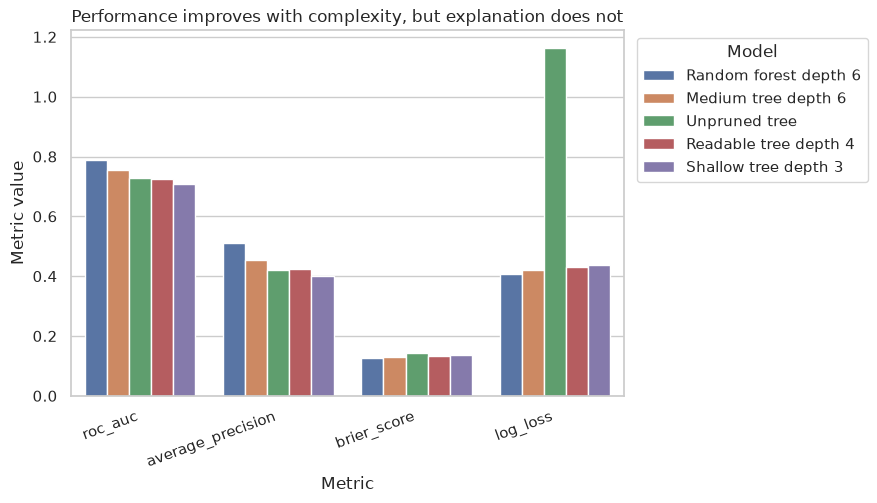

In [4]:
# Section focus: 3. Fit Trees With Different Complexity Levels.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def classification_metrics(y_true, p_hat, threshold=0.50):
    """Carry out the classification metrics step used in the 05. Tree Models, Path Logic, and Segment Rules workflow.
    
    Parameters
    ----------
    y_true : object
        Observed target or outcome values used as ground truth for metric calculation.
    p_hat : object
        Estimated probability used by the scoring, calibration, or weighting step.
    threshold : object
        Decision cutoff used to convert scores into actions or alerts.
    
    Returns
    -------
    object
        Dictionary or table of metrics used to compare model behavior.
    """
    y_hat = (p_hat >= threshold).astype(int)
    return {
        'roc_auc': roc_auc_score(y_true, p_hat),
        'average_precision': average_precision_score(y_true, p_hat),
        'brier_score': brier_score_loss(y_true, p_hat),
        'log_loss': log_loss(y_true, p_hat),
        'precision_at_0.50': precision_score(y_true, y_hat, zero_division=0),
        'recall_at_0.50': recall_score(y_true, y_hat, zero_division=0),
    }


models = {
    'Shallow tree depth 3': DecisionTreeClassifier(max_depth=3, min_samples_leaf=80, random_state=2028),
    'Readable tree depth 4': DecisionTreeClassifier(max_depth=4, min_samples_leaf=80, random_state=2028),
    'Medium tree depth 6': DecisionTreeClassifier(max_depth=6, min_samples_leaf=80, random_state=2028),
    'Unpruned tree': DecisionTreeClassifier(min_samples_leaf=20, random_state=2028),
    'Random forest depth 6': RandomForestClassifier(
        n_estimators=200,
        max_depth=6,
        min_samples_leaf=30,
        random_state=2028,
        n_jobs=-1,
    ),
}

model_rows = []
predictions = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    p_hat = model.predict_proba(X_test)[:, 1]
    predictions[name] = p_hat
    row = {'model': name, **classification_metrics(y_test, p_hat)}
    if hasattr(model, 'get_depth'):
        row['complexity'] = f"depth {model.get_depth()}, {model.get_n_leaves()} leaves"
    else:
        row['complexity'] = f"{model.n_estimators} trees, max depth {model.max_depth}"
    model_rows.append(row)

model_comparison = pd.DataFrame(model_rows).sort_values('roc_auc', ascending=False)
smart_display(model_comparison.round(3))

plot_metrics = model_comparison.melt(
    id_vars='model',
    value_vars=['roc_auc', 'average_precision', 'brier_score', 'log_loss'],
    var_name='metric',
    value_name='value',
)
fig, ax = plt.subplots(figsize=(11.5, 5.2))
sns.barplot(data=plot_metrics, x='metric', y='value', hue='model', ax=ax)
ax.set_title('Performance improves with complexity, but explanation does not')
ax.set_xlabel('Metric')
ax.set_ylabel('Metric value')
ax.legend(title='Model', loc='upper left', bbox_to_anchor=(1.01, 1.0))
plt.xticks(rotation=20, ha='right')
plt.tight_layout(rect=[0, 0, 0.78, 1])
plt.show()

The model comparison should not be read as a contest where the highest AUC automatically wins. The tree course is about **usable explanation**.

The random forest is expected to be stronger because it averages many trees. The unpruned tree may memorize small regions and can produce poor probability estimates even when its training fit is high. The shallow and readable trees are less flexible, but their paths are short enough to audit.

That is the central tradeoff: more splits can increase local fit, but every split also adds another condition that stakeholders must understand and analysts must validate.

## 4. Visualize A Readable Tree With Graphviz

A tree diagram should be read from top to bottom. Each internal node asks a yes/no question. Each terminal leaf reports the class mix among accounts that reached that leaf.

The plot below uses a depth-4 tree. This is intentionally small enough to inspect. It is not the most accurate model in the notebook, but it is the best candidate for direct path-based explanation.

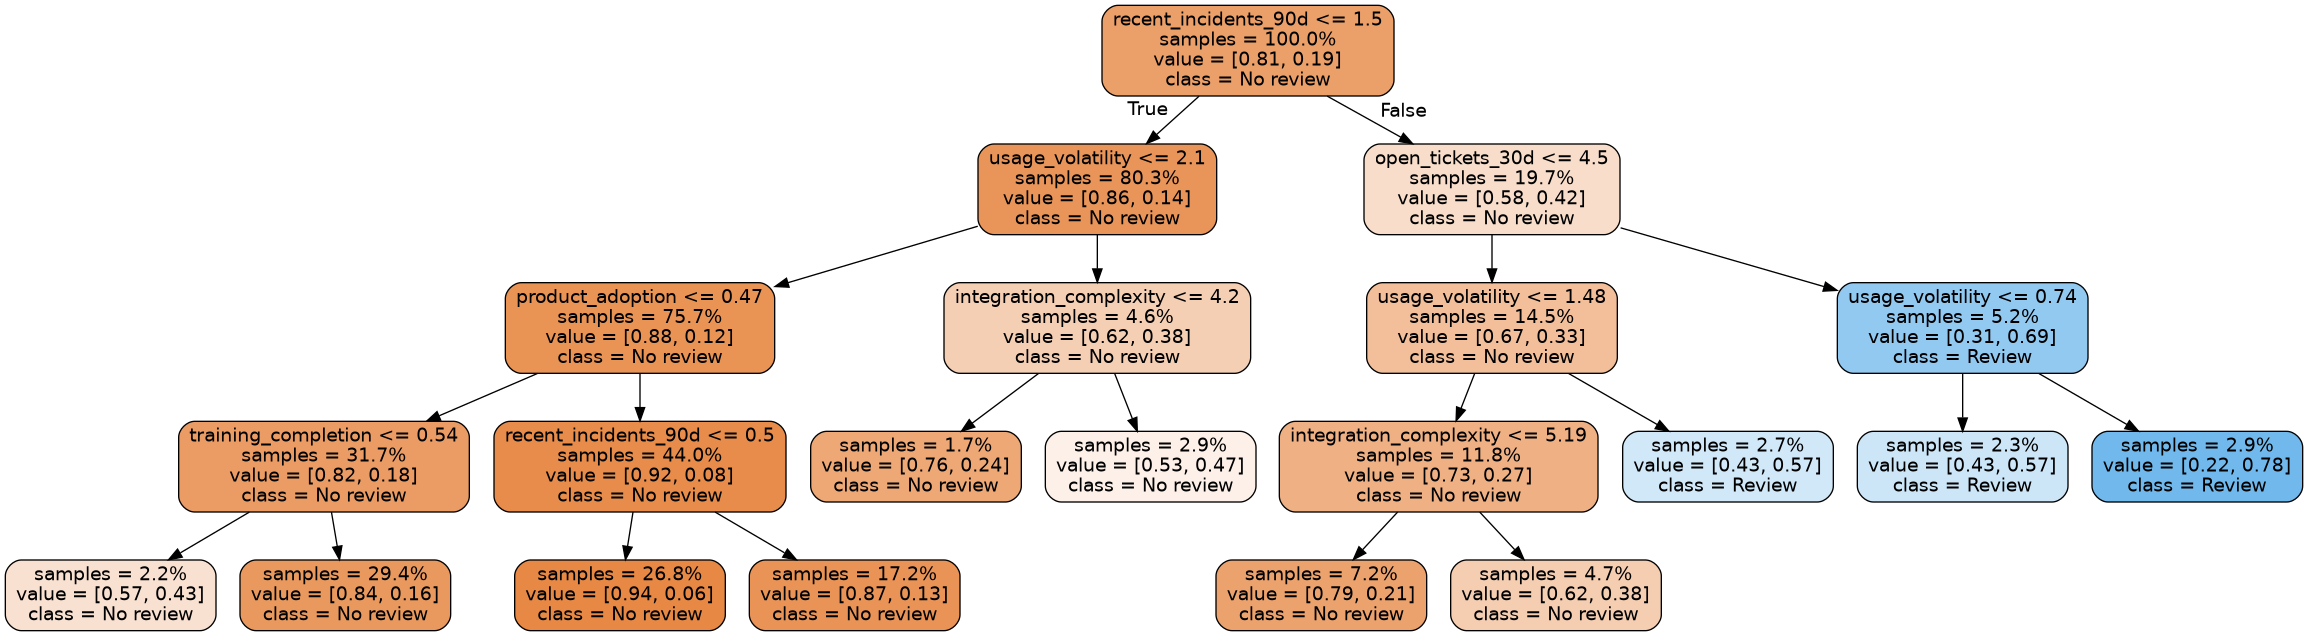

In [5]:
readable_tree = models['Readable tree depth 4']

dot = export_graphviz(
    readable_tree,
    out_file=None,
    feature_names=FEATURES,
    class_names=['No review', 'Review'],
    filled=True,
    rounded=True,
    proportion=True,
    impurity=False,
    precision=2,
    max_depth=4,
)
source = graphviz.Source(dot)
display(Image(source.pipe(format='png')))

The graph is a design object. In Visualize A Readable Tree With Graphviz, it tells us which variables are treated as causes, consequences, evidence, or decision outputs. Read the structure through the adjustment, diagnostic, or AI review it is supposed to support.


### How To Read This Tree

A node condition such as `recent_incidents_90d <= 1.5` sends accounts satisfying the condition left and accounts failing it right. A terminal leaf's displayed class proportions summarize the training accounts that reached that leaf.

A path is therefore a conjunction of split rules. For example, one path might say:

$$
\text{recent incidents} > 1.5
\quad \land \quad
\text{open tickets} > 4.5
\quad \land \quad
\text{product adoption} \le 0.45.
$$

That path defines an operational segment. The next task is to extract those segment rules in a form that can be audited in a table.

## 5. Extract Terminal Segment Rules

A tree diagram is useful for orientation, but a deployment review needs a table. Each terminal leaf should be evaluated by:

| Quantity | Interpretation |
|---|---|
| Path rule | Segment definition |
| Train support | How much evidence created the leaf |
| Test support | How much held-out evidence confirms it |
| Predicted risk | Model's leaf probability |
| Test event rate | Out-of-sample realized event rate |
| Lift | Segment event rate divided by baseline event rate |
| Action label | How the segment might be handled operationally |

A leaf with high predicted risk but tiny test support still needs support before it becomes useful. It may be an interesting hypothesis, but it is not a stable operating segment yet.

In [6]:
# Section focus: 5. Extract Terminal Segment Rules.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def format_threshold(value):
    """Format threshold for display in the 05. Tree Models, Path Logic, and Segment Rules notebook.
    
    Parameters
    ----------
    value : object
        Single numeric or text value being checked, transformed, or displayed by this helper.
    
    Returns
    -------
    object
        Intermediate result produced by the threshold calculation and reused by later cells.
    """
    if abs(value - round(value)) < 1e-6:
        return f'{value:0.0f}'
    return f'{value:0.2f}'


def extract_tree_paths(model, feature_names):
    """Extract tree paths for the 05. Tree Models, Path Logic, and Segment Rules workflow.
    
    Parameters
    ----------
    model : object
        Fitted model or model specification used by this step.
    feature_names : object
        Column or variable name used to select information from the input table.
    
    Returns
    -------
    object
        pandas.DataFrame containing the tabular result produced by this function.
    """
    tree = model.tree_
    paths = []

    def recurse(node_id, conditions):
        """Carry out the recurse step used in the 05. Tree Models, Path Logic, and Segment Rules workflow.
        
        Parameters
        ----------
        node_id : object
            Identifier of the graph node being styled or explained.
        conditions : object
            Logical conditions used to define a rule, segment, or graph relationship.
        
        Returns
        -------
        object
            Intermediate result produced by the recurse calculation and reused by later cells.
        """
        feature_id = tree.feature[node_id]
        if feature_id == -2:
            counts = tree.value[node_id][0]
            total = counts.sum()
            predicted_risk = counts[1] / total if total else np.nan
            paths.append(
                {
                    'leaf_id': node_id,
                    'path_rule': ' AND '.join(conditions) if conditions else 'All accounts',
                    'n_train_node': int(tree.n_node_samples[node_id]),
                    'predicted_risk': predicted_risk,
                    'path_length': len(conditions),
                }
            )
            return

        feature = feature_names[feature_id]
        label = FEATURE_LABELS.get(feature, feature)
        threshold = tree.threshold[node_id]
        threshold_text = format_threshold(threshold)
        recurse(tree.children_left[node_id], conditions + [f'{label} <= {threshold_text}'])
        recurse(tree.children_right[node_id], conditions + [f'{label} > {threshold_text}'])

    recurse(0, [])
    return pd.DataFrame(paths)


def score_leaf_table(model, X_train, y_train, X_test, y_test):
    """Score leaf table for the 05. Tree Models, Path Logic, and Segment Rules workflow.
    
    Parameters
    ----------
    model : object
        Fitted model or model specification used by this step.
    X_train : object
        Training feature matrix used to fit the model.
    y_train : object
        Training targets used to fit the model.
    X_test : object
        Test feature matrix used to evaluate out-of-sample behavior.
    y_test : object
        Test targets used to evaluate out-of-sample behavior.
    
    Returns
    -------
    object
        Tabular or matrix-style object produced by the leaf table workflow for later analysis.
    """
    paths = extract_tree_paths(model, FEATURES)
    train_leaf = model.apply(X_train)
    test_leaf = model.apply(X_test)
    baseline_rate = y_test.mean()

    train_summary = (
        pd.DataFrame({'leaf_id': train_leaf, TARGET: y_train.to_numpy()})
        .groupby('leaf_id', as_index=False)
        .agg(train_support=('leaf_id', 'size'), train_event_rate=(TARGET, 'mean'))
    )
    test_summary = (
        pd.DataFrame({'leaf_id': test_leaf, TARGET: y_test.to_numpy()})
        .groupby('leaf_id', as_index=False)
        .agg(test_support=('leaf_id', 'size'), test_event_rate=(TARGET, 'mean'))
    )

    table = paths.merge(train_summary, on='leaf_id', how='left').merge(test_summary, on='leaf_id', how='left')
    table['test_support_share'] = table['test_support'] / len(y_test)
    table['test_lift'] = table['test_event_rate'] / baseline_rate
    table['abs_calibration_gap'] = (table['predicted_risk'] - table['test_event_rate']).abs()
    table['action_label'] = pd.cut(
        table['predicted_risk'],
        bins=[-0.01, 0.18, 0.35, 1.01],
        labels=['Monitor in standard workflow', 'Queue for review if capacity allows', 'Prioritize specialist review'],
    )
    return table.sort_values(['predicted_risk', 'test_support'], ascending=[False, False]).reset_index(drop=True)


leaf_table = score_leaf_table(readable_tree, X_train, y_train, X_test, y_test)
leaf_display = leaf_table[
    [
        'leaf_id',
        'path_length',
        'path_rule',
        'train_support',
        'test_support',
        'predicted_risk',
        'test_event_rate',
        'test_lift',
        'abs_calibration_gap',
        'action_label',
    ]
].copy()
smart_display(leaf_display.round(3), max_width='520px')

,leaf_id,path_length,path_rule,train_support,test_support,predicted_risk,test_event_rate,test_lift,abs_calibration_gap,action_label
0,20,3,Recent incidents in last 90 days > 1.50 AND Open tickets in last 30 days > 4.50 AND Usage volatility > 0.74,146,62,0.781000,0.742000,3.816000,0.039000,Prioritize specialist review
1,19,3,Recent incidents in last 90 days > 1.50 AND Open tickets in last 30 days > 4.50 AND Usage volatility <= 0.74,115,46,0.574000,0.609000,3.130000,0.035000,Prioritize specialist review
2,17,3,Recent incidents in last 90 days > 1.50 AND Open tickets in last 30 days <= 4.50 AND Usage volatility > 1.48,136,53,0.566000,0.396000,2.038000,0.170000,Prioritize specialist review
3,11,3,Recent incidents in last 90 days <= 1.50 AND Usage volatility > 2.10 AND Integration complexity > 4.20,147,56,0.469000,0.554000,2.847000,0.084000,Prioritize specialist review
4,4,4,Recent incidents in last 90 days <= 1.50 AND Usage volatility <= 2.10 AND Product adoption <= 0.47 AND Training completion <= 0.54,113,54,0.434000,0.407000,2.095000,0.026000,Prioritize specialist review
5,16,4,Recent incidents in last 90 days > 1.50 AND Open tickets in last 30 days <= 4.50 AND Usage volatility <= 1.48 AND Integration complexity > 5.19,235,115,0.379000,0.313000,1.610000,0.066000,Prioritize specialist review
6,10,3,Recent incidents in last 90 days <= 1.50 AND Usage volatility > 2.10 AND Integration complexity <= 4.20,85,44,0.235000,0.205000,1.052000,0.031000,Queue for review if capacity allows
7,15,4,Recent incidents in last 90 days > 1.50 AND Open tickets in last 30 days <= 4.50 AND Usage volatility <= 1.48 AND Integration complexity <= 5.19,362,137,0.207000,0.263000,1.351000,0.056000,Queue for review if capacity allows
8,5,4,Recent incidents in last 90 days <= 1.50 AND Usage volatility <= 2.10 AND Product adoption <= 0.47 AND Training completion > 0.54,1483,638,0.159000,0.152000,0.782000,0.007000,Monitor in standard workflow
9,8,4,Recent incidents in last 90 days <= 1.50 AND Usage volatility <= 2.10 AND Product adoption > 0.47 AND Recent incidents in last 90 days > 0.50,868,393,0.127000,0.137000,0.707000,0.011000,Monitor in standard workflow


The metric result should be read as an operating tradeoff. In Extract Terminal Segment Rules, the best-looking score is useful only after we ask which error mode, subgroup, or capacity constraint it affects. Use the metric to sharpen the operational question: cost, risk, threshold, or action.


### Discussion of Segment Rules

This table turns a model into a governance object. The highest-risk leaves are candidates for specialist review, but not all high-risk leaves are equally trustworthy.

A good segment rule has at least four properties:

1. **Operational coherence**: the path describes a segment that a stakeholder recognizes.
2. **Enough support**: the segment is not based on a handful of accounts.
3. **Out-of-sample confirmation**: held-out event rate is reasonably close to predicted risk.
4. **Actionability**: the segment implies a useful intervention, queue, or review policy.

This is where tree interpretation becomes decision science. We do not ask only whether the tree predicts. We ask whether the segments it creates are usable decision units.

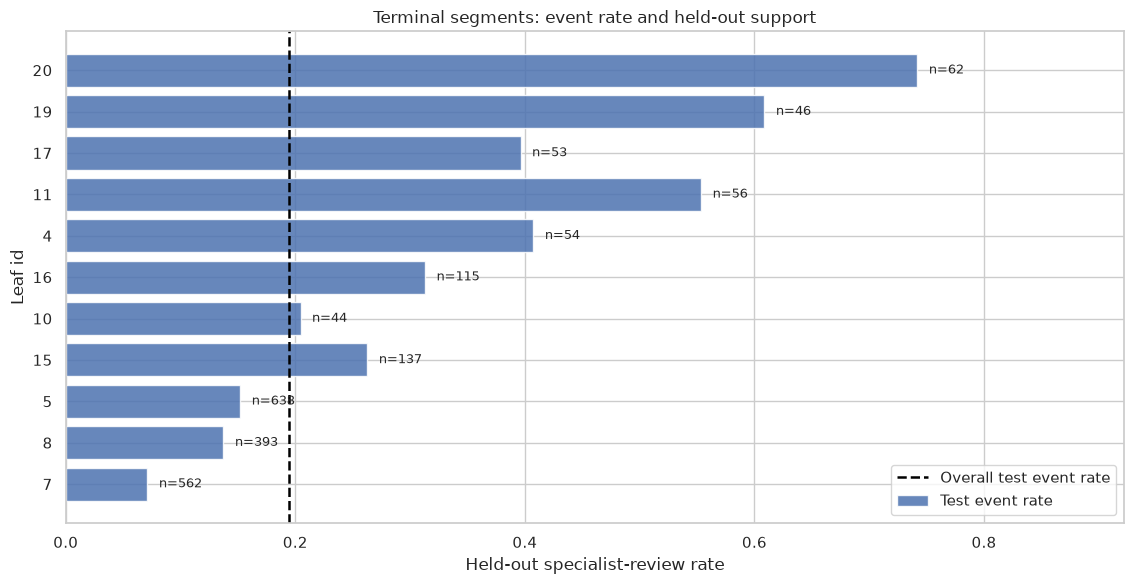

In [7]:
plot_leaf = leaf_table.sort_values('predicted_risk', ascending=True).copy()
plot_leaf['leaf_label'] = plot_leaf['leaf_id'].astype(str)

fig, ax = plt.subplots(figsize=(11.5, 6.0))
colors = np.where(plot_leaf['test_support'] < 40, '#c44e52', '#4c72b0')
ax.barh(plot_leaf['leaf_label'], plot_leaf['test_event_rate'], color=colors, alpha=0.85, label='Test event rate')
ax.axvline(y_test.mean(), color='black', linestyle='--', linewidth=1.8, label='Overall test event rate')
for _, row in plot_leaf.iterrows():
    ax.text(
        row['test_event_rate'] + 0.01,
        row['leaf_label'],
        f"n={int(row['test_support'])}",
        va='center',
        fontsize=9,
    )
ax.set_title('Terminal segments: event rate and held-out support')
ax.set_xlabel('Held-out specialist-review rate')
ax.set_ylabel('Leaf id')
ax.set_xlim(0, min(1.0, plot_leaf['test_event_rate'].max() + 0.18))
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

This figure is meant to make the pattern visible. In Discussion of Segment Rules, the shape, separation, overlap, tail behavior, or clustering should be tied back to a modeling choice or guardrail. A decision workflow should use the visual pattern to decide where the model is credible and where the next diagnostic needs attention.


### Reading The Leaf Plot

The dashed line is the overall held-out review rate. Leaves far to the right of that line are high-risk segments. The text labels show held-out support.

The plot intentionally emphasizes support because tiny leaves are dangerous. A leaf with a high event rate and 8 accounts may be a clue for further investigation, but it is not yet a reliable operating rule. A leaf with a moderately high event rate and hundreds of accounts is often more useful for capacity planning.

## 6. Explain One Account By Its Decision Path

For a single account, a tree explanation is the path it follows. This is one of the cleanest forms of local interpretability.

Mathematically, if an account lands in leaf $m$, then its prediction is

$$
\hat p(x) = \hat p_m.
$$

The explanation is the ordered set of split conditions that placed it in $R_m$.

In [8]:
# Section focus: 6. Explain One Account By Its Decision Path.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def account_path(model, account_row, feature_names):
    """Carry out the account path step used in the 05. Tree Models, Path Logic, and Segment Rules workflow.
    
    Parameters
    ----------
    model : object
        Fitted model or model specification used by this step.
    account_row : object
        Single observation or record being converted, scored, or summarized.
    feature_names : object
        Column or variable name used to select information from the input table.
    
    Returns
    -------
    object
        Tuple of outputs from this workflow, usually data, fitted objects, or diagnostics used by later cells.
    """
    tree = model.tree_
    node_indicator = model.decision_path(account_row[feature_names].to_frame().T)
    leaf_id = model.apply(account_row[feature_names].to_frame().T)[0]
    conditions = []
    for node_id in node_indicator.indices:
        if leaf_id == node_id:
            continue
        feature_id = tree.feature[node_id]
        threshold = tree.threshold[node_id]
        feature = feature_names[feature_id]
        value = account_row[feature]
        direction = '<=' if value <= threshold else '>'
        conditions.append(
            {
                'node_id': node_id,
                'feature': feature,
                'feature_label': FEATURE_LABELS.get(feature, feature),
                'account_value': value,
                'threshold': threshold,
                'condition_followed': f"{FEATURE_LABELS.get(feature, feature)} {direction} {format_threshold(threshold)}",
            }
        )
    return leaf_id, pd.DataFrame(conditions)


chosen_idx = predictions['Readable tree depth 4'].argsort()[-8]
chosen_account = X_test.iloc[chosen_idx]
leaf_id, path_table = account_path(readable_tree, chosen_account, FEATURES)
chosen_probability = readable_tree.predict_proba(chosen_account.to_frame().T)[0, 1]
chosen_actual = y_test.iloc[chosen_idx]
leaf_row = leaf_table.loc[leaf_table['leaf_id'] == leaf_id].iloc[0]

account_summary = pd.DataFrame(
    [
        {'quantity': 'Predicted specialist-review risk', 'value': chosen_probability},
        {'quantity': 'Observed held-out outcome', 'value': chosen_actual},
        {'quantity': 'Leaf id', 'value': leaf_id},
        {'quantity': 'Leaf test support', 'value': leaf_row['test_support']},
        {'quantity': 'Leaf test event rate', 'value': leaf_row['test_event_rate']},
        {'quantity': 'Leaf action label', 'value': leaf_row['action_label']},
    ]
)

smart_display(account_summary.round(3))
smart_display(path_table.round(3), max_width='520px')

,quantity,value
0,Predicted specialist-review risk,0.780822
1,Observed held-out outcome,1
2,Leaf id,20
3,Leaf test support,62
4,Leaf test event rate,0.741935
5,Leaf action label,Prioritize specialist review


,node_id,feature,feature_label,account_value,threshold,condition_followed
0,0,recent_incidents_90d,Recent incidents in last 90 days,2.000000,1.500000,Recent incidents in last 90 days > 1.50
1,12,open_tickets_30d,Open tickets in last 30 days,5.000000,4.500000,Open tickets in last 30 days > 4.50
2,18,usage_volatility,Usage volatility,0.880000,0.742000,Usage volatility > 0.74


This is the local explanation advantage of a small tree. We can show the exact sequence of questions that produced the score.

However, local path explanations can be misused. A path tells us how the model scored the account. It does not prove that changing the first condition in the path would move the account to a better outcome. For example, moving `product_adoption` above a threshold in the data matrix may change the path, but the real-world intervention required to improve adoption is a causal and operational question.

## 7. Pruning: Complexity As A Tuning Parameter

CART uses cost-complexity pruning to control tree size. A simplified version of the objective is

$$
R_\alpha(T)=R(T)+\alpha |T|,
$$

where $R(T)$ is the training loss or impurity of tree $T$, $|T|$ is a measure of tree size such as the number of terminal leaves, and $\alpha\ge 0$ penalizes complexity. Larger $\alpha$ favors smaller trees.

The practical question asks which $\alpha$ gives a tree whose segments remain interpretable while performance remains acceptable.

,ccp_alpha,depth,leaves,roc_auc,average_precision,brier_score,log_loss,precision_at_0.50,recall_at_0.50
0,0.00e+00,14,117,0.744,0.433,0.139,0.919,0.512,0.343
1,1.33e-05,14,112,0.744,0.434,0.139,0.774,0.512,0.343
2,4.80e-05,14,105,0.748,0.435,0.139,0.568,0.512,0.343
3,7.18e-05,13,99,0.747,0.435,0.139,0.553,0.512,0.343
4,9.58e-05,12,89,0.743,0.435,0.139,0.537,0.512,0.343
5,1.16e-04,12,80,0.748,0.436,0.139,0.535,0.512,0.343
6,1.49e-04,12,73,0.748,0.436,0.138,0.502,0.512,0.343
7,1.71e-04,11,65,0.752,0.438,0.138,0.470,0.512,0.343
8,1.98e-04,11,58,0.753,0.439,0.138,0.438,0.512,0.343
9,2.44e-04,11,51,0.742,0.433,0.139,0.442,0.512,0.343


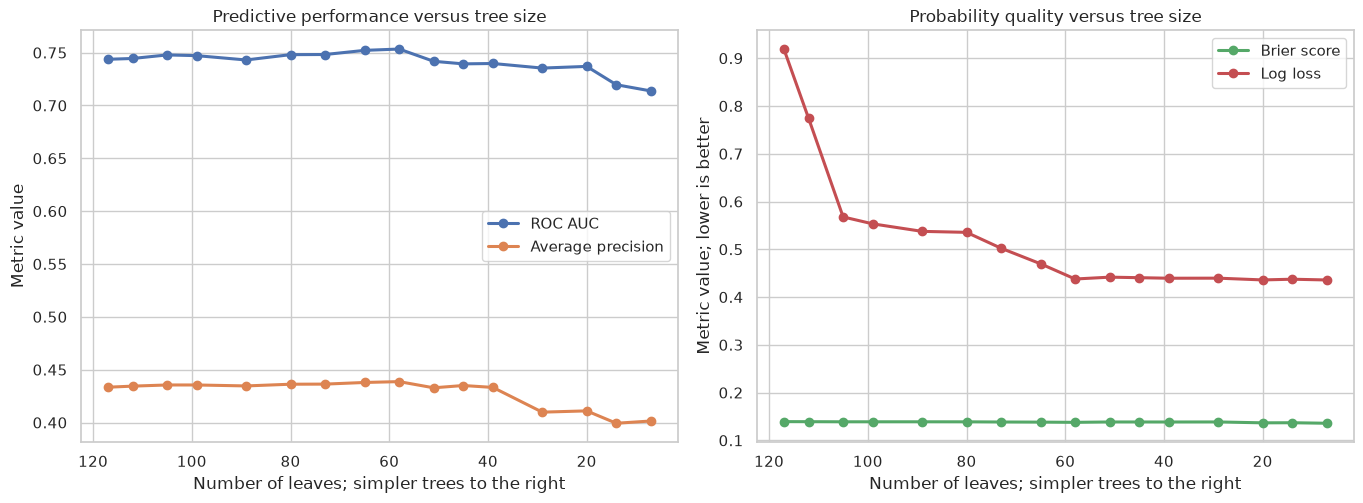

In [9]:
# Section focus: 7. Pruning: Complexity As A Tuning Parameter.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

base_tree = DecisionTreeClassifier(min_samples_leaf=30, random_state=2028)
base_tree.fit(X_train, y_train)
path = base_tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas[:-1]

quantile_alphas = np.unique(np.quantile(ccp_alphas, np.linspace(0.00, 0.95, 16)))
pruning_rows = []
for alpha in quantile_alphas:
    candidate = DecisionTreeClassifier(min_samples_leaf=30, ccp_alpha=float(alpha), random_state=2028)
    candidate.fit(X_train, y_train)
    p_hat = candidate.predict_proba(X_test)[:, 1]
    pruning_rows.append(
        {
            'ccp_alpha': alpha,
            'depth': candidate.get_depth(),
            'leaves': candidate.get_n_leaves(),
            **classification_metrics(y_test, p_hat),
        }
    )

pruning_table = pd.DataFrame(pruning_rows)
pruning_display = pruning_table.copy()
pruning_display['ccp_alpha'] = pruning_display['ccp_alpha'].map(lambda value: f'{value:.2e}')
smart_display(pruning_display.round(4))

fig, axes = plt.subplots(1, 2, figsize=(13.8, 5.2))
axes[0].plot(pruning_table['leaves'], pruning_table['roc_auc'], marker='o', linewidth=2.2, label='ROC AUC')
axes[0].plot(pruning_table['leaves'], pruning_table['average_precision'], marker='o', linewidth=2.2, label='Average precision')
axes[0].invert_xaxis()
axes[0].set_title('Predictive performance versus tree size')
axes[0].set_xlabel('Number of leaves; simpler trees to the right')
axes[0].set_ylabel('Metric value')
axes[0].legend(loc='best')

axes[1].plot(pruning_table['leaves'], pruning_table['brier_score'], marker='o', linewidth=2.2, color='#55a868', label='Brier score')
axes[1].plot(pruning_table['leaves'], pruning_table['log_loss'], marker='o', linewidth=2.2, color='#c44e52', label='Log loss')
axes[1].invert_xaxis()
axes[1].set_title('Probability quality versus tree size')
axes[1].set_xlabel('Number of leaves; simpler trees to the right')
axes[1].set_ylabel('Metric value; lower is better')
axes[1].legend(loc='best')

plt.tight_layout()
plt.show()

This result is an interpretation diagnostic. For Pruning: Complexity As A Tuning Parameter, look at whether the explanation is stable, plausible, and useful for stakeholder review. The report can use a fragile explanation as a clue, while keeping its limits visible.


### Discussion of Pruning

The pruning curve gives a more honest view of tree selection than a single default fit. The deepest tree still needs validation against pruned alternatives. Moderate pruning can improve probability quality because it removes leaves that are too tailored to training data.

For decision systems, pruning also has an interpretability role. A tree with fewer leaves creates fewer segment definitions to monitor. If two trees have similar validation performance, the smaller tree is usually easier to govern.

## 8. Stability: Are The Rules Reproducible?

A tree path can look very persuasive because it is concrete. But concreteness is not the same as stability.

A simple stability check is to refit shallow trees on bootstrap samples and inspect which features appear near the top of the tree. If the root and early splits change constantly, the path logic should be treated as exploratory rather than operational.

,root_feature,times_selected,mean_threshold,sd_threshold,selection_share
1,recent_incidents_90d,109,1.500,0.000,0.908
0,open_tickets_30d,11,3.955,0.522,0.092


,feature,times_in_first_three_internal_nodes,appearance_share
4,recent_incidents_90d,138,1.150000
6,usage_volatility,101,0.842000
3,product_adoption,69,0.575000
2,open_tickets_30d,27,0.225000
5,training_completion,20,0.167000
0,executive_sponsor,3,0.025000
1,integration_complexity,2,0.017000


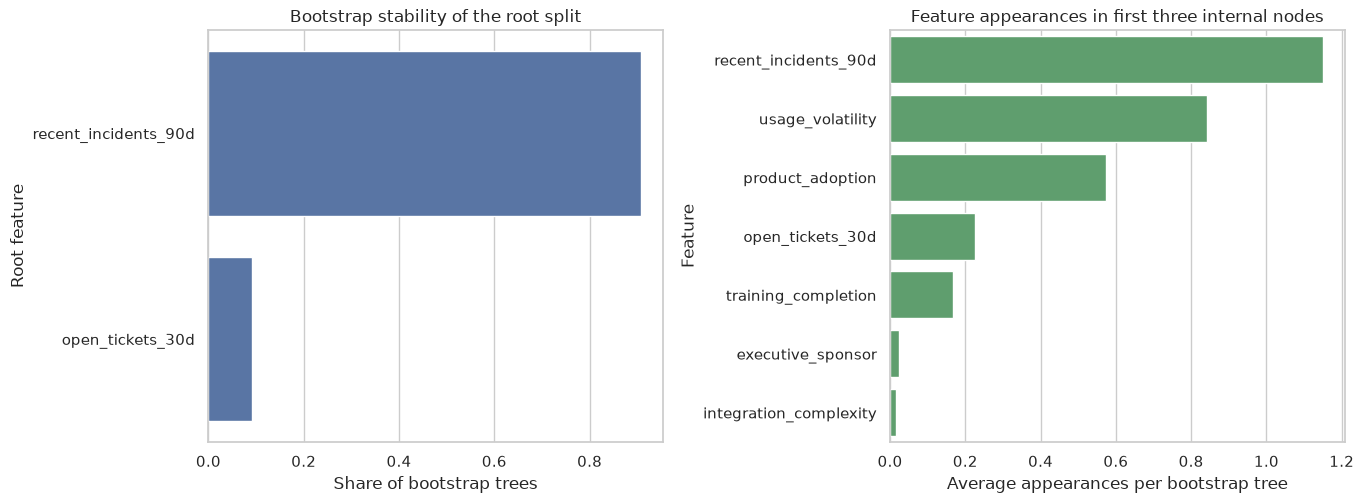

In [10]:
# Section focus: 8. Stability: Are The Rules Reproducible?.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def bootstrap_tree_stability(X, y, n_bootstrap=120, seed=2028):
    """Carry out the bootstrap tree stability step used in the 05. Tree Models, Path Logic, and Segment Rules workflow.
    
    Parameters
    ----------
    X : object
        Feature matrix used for fitting, prediction, or diagnostics.
    y : object
        Observed target values used for fitting or evaluation.
    n_bootstrap : object
        Count or size setting for the bootstrap tree stability calculation.
    seed : object
        Random seed used to make the simulation reproducible.
    
    Returns
    -------
    object
        Tuple of outputs from this workflow, usually data, fitted objects, or diagnostics used by later cells.
    """
    rng = np.random.default_rng(seed)
    rows = []
    top_node_rows = []
    X_reset = X.reset_index(drop=True)
    y_reset = y.reset_index(drop=True)

    for b in range(n_bootstrap):
        sample_idx = rng.choice(len(X_reset), len(X_reset), replace=True)
        tree = DecisionTreeClassifier(max_depth=3, min_samples_leaf=80, random_state=5000 + b)
        tree.fit(X_reset.iloc[sample_idx], y_reset.iloc[sample_idx])
        tree_ = tree.tree_
        root_feature = FEATURES[tree_.feature[0]]
        rows.append(
            {
                'bootstrap_id': b,
                'root_feature': root_feature,
                'root_threshold': tree_.threshold[0],
                'depth': tree.get_depth(),
                'leaves': tree.get_n_leaves(),
            }
        )
        internal_nodes = np.where(tree_.feature >= 0)[0]
        for rank, node_id in enumerate(internal_nodes[:3], start=1):
            top_node_rows.append(
                {
                    'bootstrap_id': b,
                    'node_rank': rank,
                    'feature': FEATURES[tree_.feature[node_id]],
                    'threshold': tree_.threshold[node_id],
                }
            )

    return pd.DataFrame(rows), pd.DataFrame(top_node_rows)


root_stability, top_node_stability = bootstrap_tree_stability(X_train, y_train)
root_summary = (
    root_stability.groupby('root_feature', as_index=False)
    .agg(
        times_selected=('root_feature', 'size'),
        mean_threshold=('root_threshold', 'mean'),
        sd_threshold=('root_threshold', 'std'),
    )
    .sort_values('times_selected', ascending=False)
)
root_summary['selection_share'] = root_summary['times_selected'] / len(root_stability)

feature_stability = (
    top_node_stability.groupby('feature', as_index=False)
    .agg(times_in_first_three_internal_nodes=('feature', 'size'))
    .sort_values('times_in_first_three_internal_nodes', ascending=False)
)
feature_stability['appearance_share'] = feature_stability['times_in_first_three_internal_nodes'] / len(root_stability)

smart_display(root_summary.round(3))
smart_display(feature_stability.round(3))

fig, axes = plt.subplots(1, 2, figsize=(13.8, 5.2))
sns.barplot(data=root_summary, x='selection_share', y='root_feature', ax=axes[0], color='#4c72b0')
axes[0].set_title('Bootstrap stability of the root split')
axes[0].set_xlabel('Share of bootstrap trees')
axes[0].set_ylabel('Root feature')

plot_top = feature_stability.head(8).copy()
sns.barplot(data=plot_top, x='appearance_share', y='feature', ax=axes[1], color='#55a868')
axes[1].set_title('Feature appearances in first three internal nodes')
axes[1].set_xlabel('Average appearances per bootstrap tree')
axes[1].set_ylabel('Feature')

plt.tight_layout()
plt.show()

This result is an interpretation diagnostic. For Stability: Are The Rules Reproducible?, look at whether the explanation is stable, plausible, and useful for stakeholder review. The model story needs qualification when a small change in the explanation setup changes the takeaway.


### Discussion of Stability

The root split is mostly stable in this run, which is reassuring. But it is not perfectly deterministic: some bootstrap samples promote ticket burden over incident burden. Lower-level splits are usually less stable than the root.

The lesson is not that trees are unusable. The lesson is that path rules should be treated as empirical objects. A segment rule should be checked across resamples, time periods, and business contexts before it becomes part of a deployed decision process.

## 9. Trees Versus Rules Versus Ensembles

A single tree is not the only way to represent segment logic.

| Approach | Strength | Weakness |
|---|---|---|
| Single shallow tree | Direct path explanation | Lower predictive ceiling |
| Pruned tree | Balances path logic and reliability | Still unstable when splits are close calls |
| Rule list or rule set | Can be more compact than a full tree | Requires separate learning or extraction strategy |
| Random forest | Strong predictive performance and variance reduction | No single path explains the model decision |
| Boosted trees | Strong ranking and nonlinear fit | Explanation usually needs post-hoc tools or aggregate diagnostics |

Luna et al. (2019) discuss the tension between tree accuracy and interpretability in high-stakes domains. Lamrini (2021) reviews decision tree induction and emphasizes interpretability as a core appeal of tree methods. Buhlmann and Yu (2002) formalize why bagging can reduce variance for unstable predictors such as trees.

## 10. Practical Rules For Decision-Science Use

When using tree path logic in a professional decision workflow:

1. Prefer the smallest tree that gives acceptable out-of-sample performance.
2. Report leaf support and event rates, alongside the tree diagram.
3. Treat a leaf as a segment hypothesis until it is validated out of sample.
4. Avoid operational rules based on tiny leaves.
5. Check whether root and early splits are stable across resamples.
6. Translate high-risk leaves into actions only when the organization can act on the path conditions.
7. Separate prediction-path explanations from causal claims.
8. Use ensembles when predictive performance matters more than single-path readability.

A tree is most valuable when it helps humans see a decision structure they can inspect and improve. It is least valuable when a complex tree is displayed as if every path were an equally reliable explanation.

## 11. Key Takeaways

- A decision tree partitions the feature space into terminal segments.
- A root-to-leaf path is a rule, and a terminal leaf is an operational segment.
- Segment rules need out-of-sample support, calibration, and actionability before deployment.
- A shallow tree can be less accurate but more useful for stakeholder reasoning.
- A deeper tree can improve fit while weakening interpretability and reliability.
- Cost-complexity pruning makes the performance-complexity tradeoff explicit.
- Bootstrap stability checks help distinguish robust path logic from sample-specific rules.
- Random forests improve prediction by aggregating trees, but they no longer provide one simple decision path.

## References

- Breiman, L., Friedman, J. H., Olshen, R. A., & Stone, C. J. (1984). *Classification and Regression Trees*. Chapman and Hall/CRC. [https://doi.org/10.1201/9781315139470](https://doi.org/10.1201/9781315139470)
- Buhlmann, P., & Yu, B. (2002). *Analyzing bagging*. *The Annals of Statistics, 30*(4), 927-961. [https://doi.org/10.1214/aos/1031689014](https://doi.org/10.1214/aos/1031689014)
- Lamrini, B. (2021). *Contribution to Decision Tree Induction with Python: A Review*. IntechOpen. [https://doi.org/10.5772/intechopen.92438](https://doi.org/10.5772/intechopen.92438)
- Landwehr, N., Hall, M., & Frank, E. (2005). *Logistic Model Trees*. *Machine Learning, 59*(1-2), 161-205. [https://doi.org/10.1007/s10994-005-0466-3](https://doi.org/10.1007/s10994-005-0466-3)
- Luna, J. M., Gennatas, E. D., Ungar, L. H., Eaton, E., Diffenderfer, E. S., Jensen, S. T., Simone, C. B., II, Friedman, J. H., Solberg, T. D., & Valdes, G. (2019). *Building more accurate decision trees with the additive tree*. *Proceedings of the National Academy of Sciences, 116*(40), 19887-19893. [https://doi.org/10.1073/pnas.1816748116](https://doi.org/10.1073/pnas.1816748116)
